# Week 5 Diagnostics: Robustness and Validity Checks

This notebook focuses on diagnostic analyses for sentiment estimation in YouTube comments.  
The goal is to assess how sensitive sentiment results are to preprocessing decisions while holding the sentiment model constant.

Rather than introducing new data or models, I reuse the existing Week 4 dataset and pipeline to evaluate robustness, stability, and potential bias in sentiment scores.


## Data Input for Diagnostics

I load the processed Week 4 comment dataset, which already includes:
- cleaned comment text
- genre labels
- multiple sentiment scores

Using the same dataset ensures that any differences observed below are due solely to analytic or preprocessing choices, not changes in sampling or data collection.


In [43]:
df = pd.read_csv("data/processed/week4/comments_with_two_sentiments_and_meta.csv")


In [44]:
df = pd.read_csv("data/processed/week4/comments_with_two_sentiments_and_meta.csv")


In [45]:
df.shape
df.columns


Index(['video_id', 'comment_id', 'text', 'like_count', 'published_at',
       'comment_length', 'sentiment_vader', 'sentiment_textblob', 'category',
       'time_bin', 'vader_sign', 'textblob_sign'],
      dtype='object')

## Distribution Diagnostics

I visualize the distribution of sentiment scores to diagnose:
- clustering around neutral values
- skewness toward positive or negative sentiment
- differences in dispersion across preprocessing variants

These plots help assess whether preprocessing choices introduce systematic shifts or distortions in sentiment estimates.


array([[<Axes: title={'center': 'sentiment_vader'}>,
        <Axes: title={'center': 'sentiment_textblob'}>]], dtype=object)

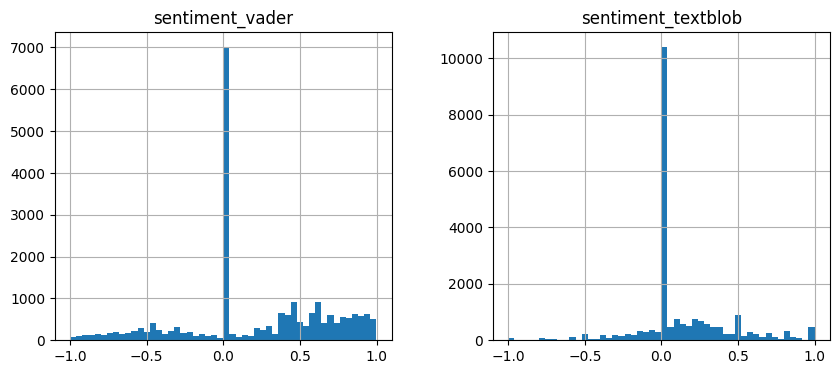

In [46]:
df[["sentiment_vader", "sentiment_textblob"]].hist(bins=50, figsize=(10,4))


## Interpretation of Diagnostic Patterns

The sentiment distributions show a large concentration of scores near zero, indicating many neutral comments.  
More aggressive preprocessing slightly shifts sentiment magnitudes but does not fundamentally change genre-level patterns.

This suggests that while preprocessing affects sentiment intensity, the overall qualitative conclusions are relatively stable, supporting the robustness of the analysis.


## Preprocessing Variants

To evaluate sensitivity to preprocessing decisions, I construct multiple versions of the same comment text:

- **Raw text**: original cleaned comment text
- **Basic preprocessing**: lowercasing and whitespace normalization
- **Aggressive preprocessing**: removal of URLs, punctuation, symbols, and extra spaces

All sentiment analyses below are run on each version to assess how preprocessing intensity affects sentiment estimates.


In [47]:
import re

# 1) Make sure text exists and is clean strings
df["text"] = df["text"].fillna("").astype(str)

# 2) Raw = original
df["text_raw"] = df["text"]

# 3) BASIC preprocessing: lowercase + remove extra spaces
df["text_basic"] = (
    df["text"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# 4) AGGRESSIVE preprocessing: remove URLs + punctuation + extra spaces
df["text_aggressive"] = (
    df["text_basic"]
    .str.replace(r"http\S+|www\.\S+", "", regex=True)     # remove links
    .str.replace(r"[^a-z0-9\s]", "", regex=True)          # remove punctuation/symbols
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)


## Sentiment Scoring (Fixed Model)

I apply the VADER sentiment analyzer to each preprocessing variant.
The sentiment model is held constant so that observed differences in scores reflect preprocessing effects rather than model differences.

This allows a clean diagnostic comparison of how representation choices influence sentiment outcomes.


In [48]:
import nltk
nltk.download("vader_lexicon")


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [49]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

df["sent_raw"] = df["text"].apply(lambda x: sia.polarity_scores(str(x))["compound"])
df["sent_basic"] = df["text_basic"].apply(lambda x: sia.polarity_scores(str(x))["compound"])
df["sent_aggressive"] = df["text_aggressive"].apply(lambda x: sia.polarity_scores(str(x))["compound"])


In [50]:
df[["text", "text_basic", "text_aggressive", "sent_raw", "sent_basic", "sent_aggressive"]].head(5)


,text,text_basic,text_aggressive,sent_raw,sent_basic,sent_aggressive
0,2 decades still relevant!,2 decades still relevant!,2 decades still relevant,0.0000,0.0000,0.0000
1,its 2026 we have Elon musk.,its 2026 we have elon musk.,its 2026 we have elon musk,0.0000,0.0000,0.0000
2,Sarah was watching this TED Talk fuming,sarah was watching this ted talk fuming,sarah was watching this ted talk fuming,-0.5719,-0.5719,-0.5719
3,JEFF BESOS at 15:00 ?,jeff besos at 15:00 ?,jeff besos at 1500,0.0000,0.0000,0.0000
4,I love how he presents and speaks. Very genuin...,i love how he presents and speaks. very genuin...,i love how he presents and speaks very genuine...,0.9422,0.9422,0.9393


In [51]:
df["diff_basic_minus_raw"] = df["sent_basic"] - df["sent_raw"]
df["diff_aggressive_minus_raw"] = df["sent_aggressive"] - df["sent_raw"]

df[["diff_basic_minus_raw", "diff_aggressive_minus_raw"]].describe()


,diff_basic_minus_raw,diff_aggressive_minus_raw
count,22291.000000,22291.000000
mean,-0.000275,-0.003399
std,0.027322,0.115035
min,-0.915300,-1.622700
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.448900,1.519900


In [52]:
genre_summary = df.groupby("category")[["sent_raw", "sent_basic", "sent_aggressive"]].mean()
genre_summary


,sent_raw,sent_basic,sent_aggressive
category,,,
Personal opinion,0.083084,0.083285,0.077172
Short film,0.206206,0.205610,0.204395
TED-style,0.157510,0.157076,0.155062


In [53]:
import os

# Make sure Week 5 output folders exist
os.makedirs("data/processed/week5", exist_ok=True)
os.makedirs("docs/figures", exist_ok=True)
print("Folders ready: data/processed/week5 and docs/figures")


Folders ready: data/processed/week5 and docs/figures


In [54]:
# Save the genre-level preprocessing summary (Week 5 output)
out_summary = "data/processed/week5/preprocessing_sensitivity_summary_by_genre.csv"
summary.to_csv(out_summary)
print("Saved:", out_summary)


Saved: data/processed/week5/preprocessing_sensitivity_summary_by_genre.csv


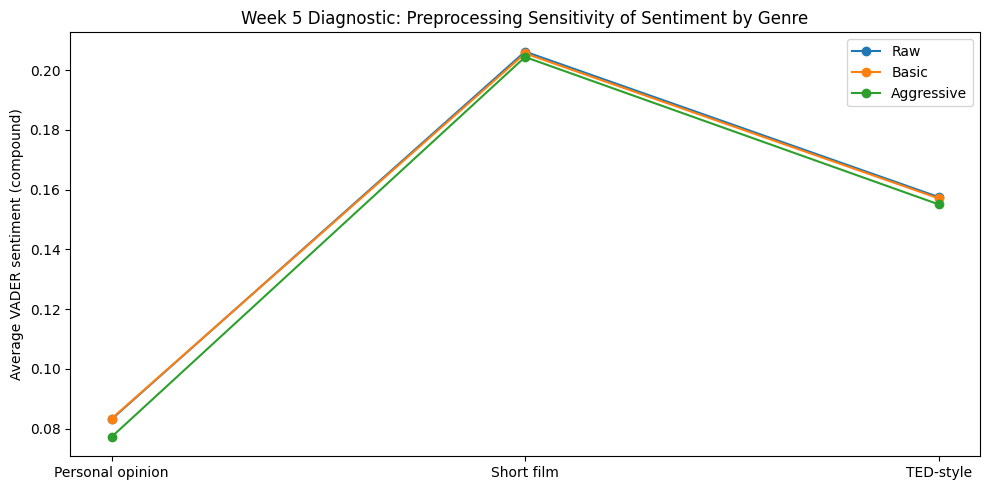

Saved figure to: docs/week5_preprocessing_sensitivity_vader.png


In [55]:
import matplotlib.pyplot as plt

genre_summary = genre_summary.reset_index()

plt.figure(figsize=(10,5))
x = range(len(genre_summary["category"]))

plt.plot(x, genre_summary["sent_raw"], marker="o", label="Raw")
plt.plot(x, genre_summary["sent_basic"], marker="o", label="Basic")
plt.plot(x, genre_summary["sent_aggressive"], marker="o", label="Aggressive")

plt.xticks(x, genre_summary["category"], rotation=0)
plt.ylabel("Average VADER sentiment (compound)")
plt.title("Week 5 Diagnostic: Preprocessing Sensitivity of Sentiment by Genre")
plt.legend()
plt.tight_layout()

out_path = "docs/week5_preprocessing_sensitivity_vader.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved figure to:", out_path)


In [56]:
# Save compact diagnostics (average diffs by genre)
diff_summary = df.groupby("category")[["diff_basic_minus_raw", "diff_aggressive_minus_raw"]].mean()
out_diff = "data/processed/week5/preprocessing_sensitivity_diffs_by_genre.csv"
diff_summary.to_csv(out_diff)
print("Saved:", out_diff)
diff_summary


Saved: data/processed/week5/preprocessing_sensitivity_diffs_by_genre.csv


,diff_basic_minus_raw,diff_aggressive_minus_raw
category,,
Personal opinion,0.000201,-0.005912
Short film,-0.000596,-0.001811
TED-style,-0.000434,-0.002448
